# 30 - LSEG/Gemma capacity-matched exact-extrema spread

**Question.** Can the promising Notebook 29 dollar-neutral Gemma mechanism be
turned into a less concentrated strategy without tuning the signal?

This is an **iterative, retrospective policy audit** on the already-opened
2025-2026 LSEG window. Notebook 29 predeclared 25% as its maximum acceptable
single-name weight; this notebook reuses that value exactly. There is no cap,
threshold, horizon, breadth, or leverage sweep.

The frozen comparator is Notebook 29's gross-1 book: 50% long exact +1 firms,
50% short exact −1 firms, one open-to-open interval, cash unless both signs
exist. The challenger retains the same firms and activity but caps every
absolute name weight at 25%. Both legs receive the same feasible budget
`min(50%, 25% × n_positive, 25% × n_negative)`; unused gross capacity remains
cash. This preserves exact dollar neutrality and never substitutes another
firm.

At 10 bps per traded side, the policy-selection gate requires capped net
Sharpe at least 0.10 above uncapped, paired net-return non-inferiority at
−1 bp/session, gross break-even above 10 bps/side, and nonnegative capped net
Sharpe in both chronological halves. The standalone quality gate requires at
least 60 active sessions, net Sharpe ≥ 0.75, maximum name weight ≤ 25%,
break-even above cost, and nonnegative half Sharpes. A strict alpha gate still
requires the capped net-return 95% interval versus cash to exclude zero.
Net return and downside-squared loss form one two-outcome paired family with
BH correction. Cost curves, attribution, and leave-one-company-out checks are
diagnostics, not selectors.

In [1]:
from __future__ import annotations

import json
import math
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.aggregators import benjamini_hochberg  # noqa: E402
from final_experiments.lib.evaluate import annualized_sharpe  # noqa: E402
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.risk_overlay import paired_block_bootstrap_difference  # noqa: E402
from final_experiments.lib.sparse_spread import (  # noqa: E402
    build_exact_extrema_targets,
    ledger_rows_to_frame,
)
from sentiment_benchmark.strategy_research.ledger import run_open_to_open_ledger  # noqa: E402
from sentiment_benchmark.strategy_research.market import OpenToOpenReturn  # noqa: E402

SEED = 20260805
COST_BPS = 10.0
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
BLOCK_LENGTH = 5
REPLICATIONS = 4_999
GROSS_EXPOSURE = 1.0
SINGLE_NAME_CAP = 0.25
INITIAL_NAV = 1_000_000.0
ARMS = ("uncapped", "capacity_capped")

GEMMA_PATH = (
    REPO_ROOT
    / "final_experiments/outputs/13_lseg_44_gemma_robustness"
    / "gemma4_26b_firm_open_aggregators.parquet"
)
NOTEBOOK29_MANIFEST = (
    REPO_ROOT
    / "final_experiments/outputs/29_lseg_gemma_exact_extrema_spread/manifest.json"
)
PRICE_PATHS = (
    REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_8m.csv",
    REPO_ROOT / "Data/derived/prices/lseg_us_sector_add11_8m.csv",
)
OUTPUT_DIR = REPO_ROOT / "final_experiments/outputs/30_lseg_gemma_capped_extrema_spread"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
apply_house_style()
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Data and return reproduction

Only Notebook 13's aggregate firm-open panel is loaded. No headline text is
displayed or persisted. The split-adjusted open return is reconstructed from
the same complete price panel and must reproduce the stored return exactly.

In [2]:
gemma = pd.read_parquet(GEMMA_PATH)
gemma["session_date"] = pd.to_datetime(gemma["session_date"]).dt.normalize()
prices = pd.concat(
    [pd.read_csv(path, parse_dates=["session_date"]) for path in PRICE_PATHS],
    ignore_index=True,
)
prices["session_date"] = pd.to_datetime(prices["session_date"]).dt.normalize()
if gemma.duplicated(["session_date", "symbol"]).any():
    raise ValueError("duplicate Gemma firm-open rows")
if prices.duplicated(["session_date", "symbol"]).any():
    raise ValueError("duplicate price rows")

open_wide = prices.pivot(index="session_date", columns="symbol", values="open").sort_index().dropna()
sessions = pd.DatetimeIndex(sorted(gemma["session_date"].unique()))
symbols = tuple(sorted(gemma["symbol"].unique()))
if len(symbols) != 44 or open_wide.shape[1] != 44:
    raise ValueError("expected the fixed 44-company population")
if not gemma.groupby("session_date")["symbol"].nunique().eq(44).all():
    raise ValueError("Gemma panel must contain all 44 firms on every session")
locations = open_wide.index.get_indexer(sessions)
if (locations < 0).any() or not np.array_equal(locations[1:], locations[:-1] + 1):
    raise ValueError("Gemma sessions must be consecutive complete-price sessions")
if locations[-1] + 1 >= len(open_wide.index):
    raise ValueError("last signal session has no next complete open")

return_rows: list[OpenToOpenReturn] = []
recomputed_rows: list[dict[str, object]] = []
for session, location in zip(sessions, locations, strict=True):
    next_session = open_wide.index[location + 1]
    values = open_wide.loc[next_session, list(symbols)] / open_wide.loc[session, list(symbols)] - 1.0
    for symbol, value in values.items():
        return_rows.append(
            OpenToOpenReturn(
                symbol=symbol,
                session=str(session.date()),
                next_session=str(next_session.date()),
                value=float(value),
            )
        )
        recomputed_rows.append(
            {"session_date": session, "symbol": symbol, "recomputed_raw_open_h1": float(value)}
        )
return_audit = gemma[["session_date", "symbol", "raw_open_h1"]].merge(
    pd.DataFrame(recomputed_rows),
    on=["session_date", "symbol"],
    how="left",
    validate="1:1",
)
return_audit["absolute_error"] = (
    return_audit["raw_open_h1"] - return_audit["recomputed_raw_open_h1"]
).abs()
if return_audit["absolute_error"].max() > 1e-12:
    raise RuntimeError("price-derived returns do not reproduce Notebook 13")
coverage = pd.DataFrame(
    [
        {
            "firm_open_rows": len(gemma),
            "sessions": len(sessions),
            "companies": len(symbols),
            "first_entry_session": sessions.min(),
            "last_entry_session": sessions.max(),
            "last_return_end": open_wide.index[locations[-1] + 1],
            "max_return_reproduction_error": float(return_audit["absolute_error"].max()),
        }
    ]
)
display(coverage)

,firm_open_rows,sessions,companies,first_entry_session,last_entry_session,last_return_end,max_return_reproduction_error
0,7348,167,44,2025-10-27,2026-06-26,2026-06-29,0.000000


## Frozen target construction and concentration audit

Both paths trade the exact same signs on the exact same sessions. The cap can
only reduce both legs together; it cannot add a name, change a sign, or create
net exposure.

In [3]:
uncapped_targets, uncapped_audit = build_exact_extrema_targets(
    gemma,
    gross_exposure=GROSS_EXPOSURE,
    minimum_names_per_side=1,
)
capped_targets, capped_audit = build_exact_extrema_targets(
    gemma,
    gross_exposure=GROSS_EXPOSURE,
    minimum_names_per_side=1,
    single_name_cap=SINGLE_NAME_CAP,
)
if not uncapped_audit["eligible"].equals(capped_audit["eligible"]):
    raise RuntimeError("cap changed signal activity")
if capped_audit["net_exposure"].abs().max() > 1e-12:
    raise RuntimeError("capped book is not dollar-neutral")
if capped_audit["max_abs_name_weight"].max() > SINGLE_NAME_CAP + 1e-12:
    raise RuntimeError("capped book violates the frozen name cap")
if (capped_audit["gross_exposure"] - uncapped_audit["gross_exposure"] > 1e-12).any():
    raise RuntimeError("cap increased gross exposure")

active = capped_audit["eligible"]
construction_audit = pd.DataFrame(
    [
        {
            "sessions": len(capped_audit),
            "active_sessions": int(active.sum()),
            "capacity_reduced_sessions": int(
                (
                    capped_audit["gross_exposure"]
                    < uncapped_audit["gross_exposure"] - 1e-12
                ).sum()
            ),
            "full_gross_capped_sessions": int(capped_audit["gross_exposure"].eq(1.0).sum()),
            "uncapped_mean_gross_exposure": float(uncapped_audit["gross_exposure"].mean()),
            "capped_mean_gross_exposure": float(capped_audit["gross_exposure"].mean()),
            "capped_mean_active_gross_exposure": float(
                capped_audit.loc[active, "gross_exposure"].mean()
            ),
            "uncapped_max_name_weight": float(uncapped_audit["max_abs_name_weight"].max()),
            "capped_max_name_weight": float(capped_audit["max_abs_name_weight"].max()),
            "mean_unused_gross_capacity": float(capped_audit["unused_gross_capacity"].mean()),
        }
    ]
)
display(construction_audit.T)

,0
sessions,167.000000
active_sessions,80.000000
capacity_reduced_sessions,66.000000
full_gross_capped_sessions,14.000000
uncapped_mean_gross_exposure,0.479042
capped_mean_gross_exposure,0.281437
capped_mean_active_gross_exposure,0.587500
uncapped_max_name_weight,0.500000
capped_max_name_weight,0.250000
mean_unused_gross_capacity,0.718563


## Drift-aware ledger and exact Notebook 29 reproduction

In [4]:
def fold_final_liquidation(frame: pd.DataFrame) -> pd.DataFrame:
    liquidation = frame.loc[frame["final_liquidation"]]
    intervals = frame.loc[~frame["final_liquidation"]].copy().reset_index(drop=True)
    if len(liquidation) != 1 or intervals.empty:
        raise RuntimeError("expected one final liquidation after non-empty intervals")
    final = liquidation.iloc[0]
    last = intervals.index[-1]
    intervals.loc[last, "net_return"] = (
        (1.0 + intervals.loc[last, "net_return"]) * (1.0 + final["net_return"]) - 1.0
    )
    intervals.loc[last, "turnover"] += final["turnover"]
    intervals.loc[last, "cost"] += final["cost"]
    intervals.loc[last, "end_nav"] = final["end_nav"]
    intervals["downside_sq"] = np.minimum(intervals["net_return"], 0.0) ** 2
    return intervals


def run_targets(
    target_rows: tuple,
    return_values: list[OpenToOpenReturn],
    *,
    cost_bps: float,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    ledger = run_open_to_open_ledger(
        target_rows,
        return_values,
        cost_rate_per_side=cost_bps / 10_000.0,
        initial_nav_usd=INITIAL_NAV,
        force_final_liquidation=True,
    )
    full = ledger_rows_to_frame(ledger)
    return fold_final_liquidation(full), full


def summarize_path(daily: pd.DataFrame, *, cost_bps: float) -> dict[str, float | int]:
    gross = daily["gross_return"].to_numpy(dtype=float)
    net = daily["net_return"].to_numpy(dtype=float)
    gross_equity = np.cumprod(1.0 + gross)
    net_equity = np.cumprod(1.0 + net)
    with_start = np.r_[1.0, net_equity]
    peaks = np.maximum.accumulate(with_start)
    turnover_sum = float(daily["turnover"].sum())
    return {
        "n_sessions": int(len(daily)),
        "active_sessions": int(daily["gross_exposure"].gt(0).sum()),
        "mean_gross": float(np.mean(gross)),
        "mean_net": float(np.mean(net)),
        "sharpe_gross": annualized_sharpe(pd.Series(gross)),
        "sharpe_net": annualized_sharpe(pd.Series(net)),
        "ann_vol_net": float(np.std(net, ddof=1) * math.sqrt(252)),
        "total_return_gross": float(gross_equity[-1] - 1.0),
        "total_return_net": float(net_equity[-1] - 1.0),
        "max_drawdown": float(np.min(with_start / peaks - 1.0)),
        "mean_turnover": float(turnover_sum / len(daily)),
        "total_turnover": turnover_sum,
        "mean_gross_exposure": float(daily["gross_exposure"].mean()),
        "mean_active_names": float(daily.loc[daily["gross_exposure"].gt(0), "active_names"].mean()),
        "max_abs_net_exposure": float(daily["net_exposure"].abs().max()),
        "breakeven_bps_per_side": float(10_000.0 * gross.sum() / turnover_sum),
        "cost_bps_per_side": cost_bps,
    }


daily_paths = {}
ledger_paths = {}
for arm, target_rows in zip(ARMS, (uncapped_targets, capped_targets), strict=True):
    daily_paths[arm], ledger_paths[arm] = run_targets(
        target_rows,
        return_rows,
        cost_bps=COST_BPS,
    )
results = pd.DataFrame(
    [
        {"arm": arm, **summarize_path(daily_paths[arm], cost_bps=COST_BPS)}
        for arm in ARMS
    ]
)

notebook29 = json.loads(NOTEBOOK29_MANIFEST.read_text())
reference = notebook29["results"]
reproduced = results.set_index("arm").loc["uncapped"]
for metric in (
    "mean_gross",
    "mean_net",
    "sharpe_gross",
    "sharpe_net",
    "total_return_gross",
    "total_return_net",
    "max_drawdown",
    "mean_turnover",
    "breakeven_bps_per_side",
):
    if not np.isclose(float(reproduced[metric]), float(reference[metric]), atol=1e-10):
        raise RuntimeError(f"Notebook 29 reproduction failed for {metric}")
reproduction = pd.DataFrame(
    [
        {
            "metrics_checked": 9,
            "all_match_within_1e_10": True,
            "reference_notebook": "29_lseg_gemma_exact_extrema_spread.ipynb",
        }
    ]
)
display(results.T)
display(reproduction)

,0,1
arm,uncapped,capacity_capped
n_sessions,167,167
active_sessions,80,80
mean_gross,0.001410,0.001049
mean_net,0.000649,0.000597
sharpe_gross,2.557885,2.945235
sharpe_net,1.184605,1.696870
ann_vol_net,0.138017,0.088723
total_return_gross,0.257323,0.188166
total_return_net,0.107433,0.102037


,metrics_checked,all_match_within_1e_10,reference_notebook
0,9,True,29_lseg_gemma_exact_extrema_spread.ipynb


## Paired return, downside, and standalone-alpha inference

Positive paired estimates favour the cap. For downside, the subtraction is
uncapped minus capped so lower capped loss is positive. BH is applied once
across these two policy-comparison outcomes. The separate capped-versus-cash
return interval is the predeclared standalone alpha gate.

In [5]:
inference_rows = []
for outcome_offset, outcome in enumerate(("net_return", "downside_sq")):
    if outcome == "net_return":
        challenger = daily_paths["capacity_capped"]
        baseline = daily_paths["uncapped"]
    else:
        challenger = daily_paths["uncapped"]
        baseline = daily_paths["capacity_capped"]
    estimate = paired_block_bootstrap_difference(
        challenger,
        baseline,
        value_col=outcome,
        block_length=BLOCK_LENGTH,
        replications=REPLICATIONS,
        seed=SEED + outcome_offset,
    )
    inference_rows.append(
        {
            "outcome": outcome,
            "positive_favours_cap": True,
            **estimate,
        }
    )
paired_inference = pd.DataFrame(inference_rows)
paired_inference["bh_reject_q05"] = benjamini_hochberg(
    paired_inference["p_two_sided"].tolist(),
    q=0.05,
)
cash = daily_paths["capacity_capped"][["session_date"]].copy()
cash["net_return"] = 0.0
capped_vs_cash = pd.DataFrame(
    [
        {
            "comparison": "capacity_capped_minus_cash",
            **paired_block_bootstrap_difference(
                daily_paths["capacity_capped"],
                cash,
                value_col="net_return",
                block_length=BLOCK_LENGTH,
                replications=REPLICATIONS,
                seed=SEED + 10,
            ),
        }
    ]
)
display(paired_inference)
display(capped_vs_cash)

,outcome,positive_favours_cap,n_sessions,mean_difference,ci_low,ci_high,p_two_sided,block_length,replications,seed,bh_reject_q05
0,net_return,True,167,-0.000051,-0.000548,0.000429,0.831800,5,4999,20260805,False
1,downside_sq,True,167,0.000021,0.000008,0.000040,0.012000,5,4999,20260806,True


,comparison,n_sessions,mean_difference,ci_low,ci_high,p_two_sided,block_length,replications,seed
0,capacity_capped_minus_cash,167,0.000597,-0.000097,0.001322,0.099800,5,4999,20260815


## Cost and chronological-half stability

Each half is independently initialised and liquidated. The cap is not
recalibrated in either half.

In [6]:
cost_rows = []
for cost in COST_GRID:
    for arm, target_rows in zip(ARMS, (uncapped_targets, capped_targets), strict=True):
        daily, _ = run_targets(target_rows, return_rows, cost_bps=cost)
        cost_rows.append({"arm": arm, **summarize_path(daily, cost_bps=cost)})
cost_curve = pd.DataFrame(cost_rows)

midpoint = len(sessions) // 2
half_indices = {"first_half": sessions[:midpoint], "second_half": sessions[midpoint:]}
temporal_rows = []
for period, index in half_indices.items():
    half_panel = gemma.loc[gemma["session_date"].isin(index)].copy()
    half_return_sessions = {str(session.date()) for session in index}
    half_returns = [row for row in return_rows if row.session in half_return_sessions]
    half_targets = {
        "uncapped": build_exact_extrema_targets(half_panel)[0],
        "capacity_capped": build_exact_extrema_targets(
            half_panel,
            single_name_cap=SINGLE_NAME_CAP,
        )[0],
    }
    for arm in ARMS:
        daily, _ = run_targets(half_targets[arm], half_returns, cost_bps=COST_BPS)
        temporal_rows.append(
            {"period": period, "arm": arm, **summarize_path(daily, cost_bps=COST_BPS)}
        )
temporal = pd.DataFrame(temporal_rows)
display(cost_curve)
display(temporal)

,arm,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,ann_vol_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,mean_gross_exposure,mean_active_names,max_abs_net_exposure,breakeven_bps_per_side,cost_bps_per_side
0,uncapped,167,80,0.001410,0.001410,2.557885,2.557885,0.138922,0.257323,0.257323,-0.062932,0.760890,127.068685,0.479042,3.250000,0.000000,18.532283,0.000000
1,capacity_capped,167,80,0.001049,0.001049,2.945235,2.945235,0.089731,0.188166,0.188166,-0.040729,0.451140,75.340303,0.281437,3.250000,0.000000,23.246192,0.000000
2,uncapped,167,80,0.001410,0.001334,2.557885,2.421882,0.138806,0.257323,0.241479,-0.064502,0.760932,127.075660,0.479042,3.250000,0.000000,18.531266,1.000000
3,capacity_capped,167,80,0.001049,0.001004,2.945235,2.822228,0.089614,0.188166,0.179265,-0.041630,0.451156,75.343011,0.281437,3.250000,0.000000,23.245357,1.000000
4,uncapped,167,80,0.001410,0.001258,2.557885,2.285542,0.138695,0.257323,0.225832,-0.066069,0.760974,127.082637,0.479042,3.250000,0.000000,18.530248,2.000000
5,capacity_capped,167,80,0.001049,0.000958,2.945235,2.698778,0.089500,0.188166,0.170429,-0.042530,0.451172,75.345719,0.281437,3.250000,0.000000,23.244522,2.000000
6,uncapped,167,80,0.001410,0.001030,2.557885,1.874655,0.138398,0.257323,0.180043,-0.070756,0.761099,127.103583,0.479042,3.250000,0.000000,18.527195,5.000000
7,capacity_capped,167,80,0.001049,0.000823,2.945235,2.325906,0.089181,0.188166,0.144308,-0.045226,0.451221,75.353846,0.281437,3.250000,0.000000,23.242014,5.000000
8,uncapped,167,80,0.001410,0.000649,2.557885,1.184605,0.138017,0.257323,0.107433,-0.078524,0.761310,127.138698,0.479042,3.250000,0.000000,18.522077,10.000000
9,capacity_capped,167,80,0.001049,0.000597,2.945235,1.696870,0.088723,0.188166,0.102037,-0.049705,0.451303,75.367628,0.281437,3.250000,0.000000,23.237764,10.000000


,period,arm,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,ann_vol_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,mean_gross_exposure,mean_active_names,max_abs_net_exposure,breakeven_bps_per_side,cost_bps_per_side
0,first_half,uncapped,83,28,0.000417,-0.000217,0.718743,-0.377724,0.144994,0.031631,-0.021249,-0.078524,0.634691,52.679338,0.337349,2.964286,0.000000,6.575769,10.000000
1,first_half,capacity_capped,83,28,0.000369,0.000004,1.054197,0.011072,0.087171,0.029801,-0.000919,-0.049705,0.365297,30.319626,0.192771,2.964286,0.000000,10.104843,10.000000
2,second_half,uncapped,84,52,0.002391,0.001505,4.628065,2.912176,0.130199,0.218772,0.131476,-0.027225,0.886421,74.459360,0.619048,3.403846,0.000000,26.973985,10.000000
3,second_half,capacity_capped,84,52,0.001720,0.001184,4.793089,3.323360,0.089775,0.153782,0.103051,-0.014145,0.536286,45.048002,0.369048,3.403846,0.000000,32.076897,10.000000


## Post-result company attribution and leave-one-out diagnostics

These diagnostics assess dependence; they do not change the cap or select a
company subset.

In [7]:
return_matrix = np.vstack(
    [
        (
            open_wide.loc[open_wide.index[location + 1], list(symbols)]
            / open_wide.loc[session, list(symbols)]
            - 1.0
        ).to_numpy(dtype=float)
        for session, location in zip(sessions, locations, strict=True)
    ]
)


def target_matrix(target_rows: tuple) -> np.ndarray:
    return np.vstack(
        [np.array([target.weights()[symbol] for symbol in symbols], dtype=float) for target in target_rows]
    )


uncapped_weights = target_matrix(uncapped_targets)
capped_weights = target_matrix(capped_targets)
attribution = pd.DataFrame({"symbol": symbols})
for arm, weights in (("uncapped", uncapped_weights), ("capacity_capped", capped_weights)):
    contribution = weights * return_matrix
    attribution[f"{arm}_gross_contribution"] = contribution.sum(axis=0)
    attribution[f"{arm}_active_sessions"] = (np.abs(weights) > 1e-12).sum(axis=0)
    total = float(contribution.sum())
    attribution[f"{arm}_share_of_total_gross"] = contribution.sum(axis=0) / total
attribution = attribution.sort_values(
    "capacity_capped_gross_contribution",
    ascending=False,
    ignore_index=True,
)

leave_one_out_rows = []
for removed_symbol in symbols:
    reduced_panel = gemma.loc[gemma["symbol"].ne(removed_symbol)].copy()
    reduced_targets, reduced_audit = build_exact_extrema_targets(
        reduced_panel,
        single_name_cap=SINGLE_NAME_CAP,
    )
    reduced_returns = [row for row in return_rows if row.symbol != removed_symbol]
    reduced_daily, _ = run_targets(reduced_targets, reduced_returns, cost_bps=COST_BPS)
    leave_one_out_rows.append(
        {
            "removed_symbol": removed_symbol,
            "eligible_sessions": int(reduced_audit["eligible"].sum()),
            **summarize_path(reduced_daily, cost_bps=COST_BPS),
        }
    )
leave_one_out = pd.DataFrame(leave_one_out_rows).sort_values(
    "sharpe_net",
    ascending=True,
    ignore_index=True,
)
gs_row = attribution.loc[attribution["symbol"].eq("GS")].iloc[0]
dependence_summary = pd.DataFrame(
    [
        {
            "leave_one_out_replays": len(leave_one_out),
            "positive_net_return_replays": int(leave_one_out["total_return_net"].gt(0).sum()),
            "minimum_net_sharpe": float(leave_one_out["sharpe_net"].min()),
            "median_net_sharpe": float(leave_one_out["sharpe_net"].median()),
            "maximum_net_sharpe": float(leave_one_out["sharpe_net"].max()),
            "uncapped_gs_gross_share": float(gs_row["uncapped_share_of_total_gross"]),
            "capped_gs_gross_share": float(gs_row["capacity_capped_share_of_total_gross"]),
            "largest_capped_company_gross_share": float(
                attribution["capacity_capped_share_of_total_gross"].max()
            ),
        }
    ]
)
display(attribution.head(12))
display(dependence_summary.T)

,symbol,uncapped_gross_contribution,uncapped_active_sessions,uncapped_share_of_total_gross,capacity_capped_gross_contribution,capacity_capped_active_sessions,capacity_capped_share_of_total_gross
0,GS,0.121202,55,0.514685,0.071013,55,0.405468
1,NVDA,0.008685,24,0.036881,0.016900,24,0.096495
2,AVGO,0.022067,7,0.093706,0.013077,7,0.074667
3,LLY,0.024743,17,0.105071,0.011740,17,0.067031
4,NFLX,0.006901,13,0.029306,0.011589,13,0.066169
5,META,0.022168,7,0.094138,0.011084,7,0.063288
6,WMT,0.016887,7,0.071710,0.007589,7,0.043329
7,XOM,0.011568,4,0.049126,0.006575,4,0.037543
8,FCX,0.006550,2,0.027816,0.006550,2,0.037401
9,NEM,0.009456,2,0.040155,0.006463,2,0.036903


,0
leave_one_out_replays,44.000000
positive_net_return_replays,44.000000
minimum_net_sharpe,0.395087
median_net_sharpe,1.696870
maximum_net_sharpe,2.396083
uncapped_gs_gross_share,0.514685
capped_gs_gross_share,0.405468
largest_capped_company_gross_share,0.405468


## Frozen gates

In [8]:
result_index = results.set_index("arm")
uncapped = result_index.loc["uncapped"]
capped = result_index.loc["capacity_capped"]
paired_return = paired_inference.set_index("outcome").loc["net_return"]
capped_cash_return = capped_vs_cash.iloc[0]
temporal_index = temporal.set_index(["period", "arm"])
capped_half_sharpes = {
    period: float(temporal_index.loc[(period, "capacity_capped"), "sharpe_net"])
    for period in half_indices
}
policy_selection_gate = bool(
    capped["sharpe_net"] >= uncapped["sharpe_net"] + 0.10
    and paired_return["ci_low"] * 10_000 >= -1.0
    and capped["breakeven_bps_per_side"] > COST_BPS
    and all(value >= 0 for value in capped_half_sharpes.values())
)
standalone_quality_gate = bool(
    capped["active_sessions"] >= 60
    and capped["sharpe_net"] >= 0.75
    and construction_audit.loc[0, "capped_max_name_weight"] <= SINGLE_NAME_CAP + 1e-12
    and capped["breakeven_bps_per_side"] > COST_BPS
    and all(value >= 0 for value in capped_half_sharpes.values())
)
alpha_gate = bool(
    capped_cash_return["ci_low"] > 0
    and capped_cash_return["p_two_sided"] < 0.05
    and capped["mean_net"] > 0
)
gates = pd.DataFrame(
    [
        {
            "policy_selection_gate": policy_selection_gate,
            "standalone_quality_gate": standalone_quality_gate,
            "alpha_gate": alpha_gate,
            "capped_minus_uncapped_sharpe": float(capped["sharpe_net"] - uncapped["sharpe_net"]),
            "capped_minus_uncapped_bps_session": float(
                paired_return["mean_difference"] * 10_000
            ),
            "paired_ci_low_bps_session": float(paired_return["ci_low"] * 10_000),
            "paired_ci_high_bps_session": float(paired_return["ci_high"] * 10_000),
            "paired_p_two_sided": float(paired_return["p_two_sided"]),
            "paired_return_bh_reject": bool(paired_return["bh_reject_q05"]),
            "capped_vs_cash_ci_low_bps_session": float(capped_cash_return["ci_low"] * 10_000),
            "capped_vs_cash_p_two_sided": float(capped_cash_return["p_two_sided"]),
            "capped_breakeven_bps_per_side": float(capped["breakeven_bps_per_side"]),
            "first_half_capped_net_sharpe": capped_half_sharpes["first_half"],
            "second_half_capped_net_sharpe": capped_half_sharpes["second_half"],
            "capped_max_name_weight": float(construction_audit.loc[0, "capped_max_name_weight"]),
        }
    ]
)
display(gates.T)

,0
policy_selection_gate,False
standalone_quality_gate,True
alpha_gate,False
capped_minus_uncapped_sharpe,0.512265
capped_minus_uncapped_bps_session,-0.513694
paired_ci_low_bps_session,-5.483235
paired_ci_high_bps_session,4.291029
paired_p_two_sided,0.831800
paired_return_bh_reject,False
capped_vs_cash_ci_low_bps_session,-0.973107


## Figures

findfont: Failed to find font weight medium, now using 400.


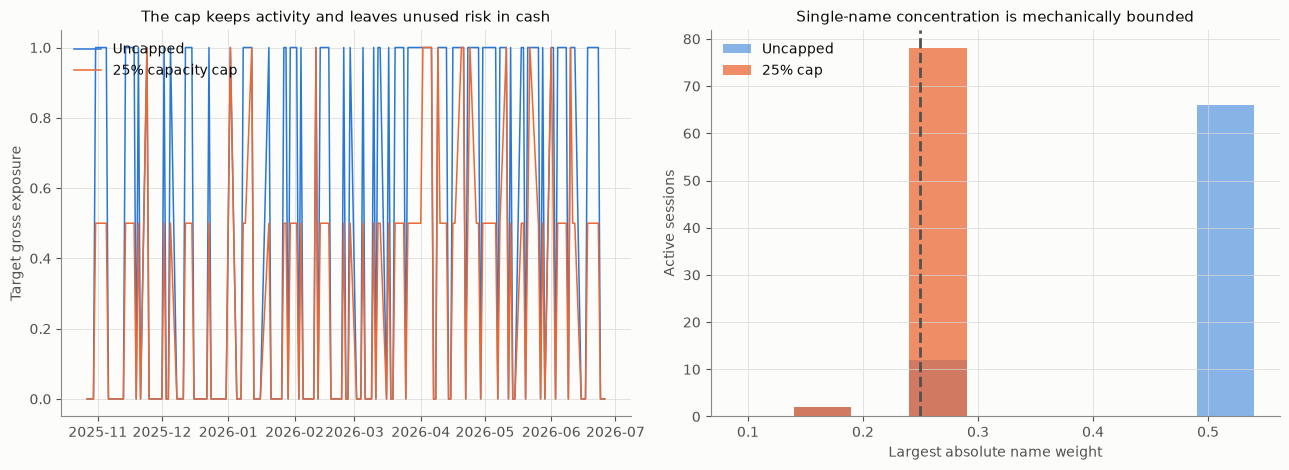

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(
    uncapped_audit["session_date"],
    uncapped_audit["gross_exposure"],
    color=CATEGORICAL[0],
    linewidth=1.1,
    label="Uncapped",
)
axes[0].plot(
    capped_audit["session_date"],
    capped_audit["gross_exposure"],
    color=CATEGORICAL[1],
    linewidth=1.1,
    label="25% capacity cap",
)
axes[0].set_ylabel("Target gross exposure")
axes[0].set_title("The cap keeps activity and leaves unused risk in cash")
axes[0].legend(loc="upper left")
active_uncapped = uncapped_audit.loc[uncapped_audit["eligible"], "max_abs_name_weight"]
active_capped = capped_audit.loc[capped_audit["eligible"], "max_abs_name_weight"]
bins = np.arange(0.09, 0.56, 0.05)
axes[1].hist(active_uncapped, bins=bins, alpha=0.55, color=CATEGORICAL[0], label="Uncapped")
axes[1].hist(active_capped, bins=bins, alpha=0.75, color=CATEGORICAL[1], label="25% cap")
axes[1].axvline(SINGLE_NAME_CAP, color=INK["reference"], linestyle="--")
axes[1].set_xlabel("Largest absolute name weight")
axes[1].set_ylabel("Active sessions")
axes[1].set_title("Single-name concentration is mechanically bounded")
axes[1].legend(loc="upper left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "exposure_and_concentration.png", dpi=170, bbox_inches="tight")
plt.show()

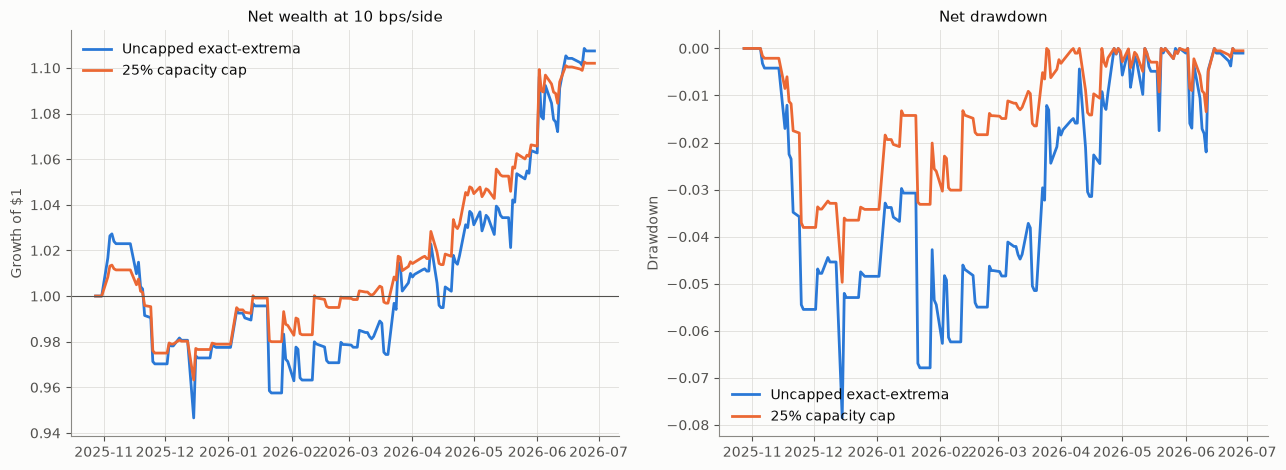

In [10]:
labels = {"uncapped": "Uncapped exact-extrema", "capacity_capped": "25% capacity cap"}
colours = {"uncapped": CATEGORICAL[0], "capacity_capped": CATEGORICAL[1]}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for arm in ARMS:
    daily = daily_paths[arm]
    equity = (1.0 + daily["net_return"]).cumprod()
    with_start = np.r_[1.0, equity]
    drawdown = equity / np.maximum.accumulate(with_start)[1:] - 1.0
    axes[0].plot(daily["return_end_date"], equity, color=colours[arm], label=labels[arm])
    axes[1].plot(daily["return_end_date"], drawdown, color=colours[arm], label=labels[arm])
axes[0].axhline(1.0, color=INK["reference"], linewidth=0.8)
axes[0].set_ylabel("Growth of $1")
axes[0].set_title("Net wealth at 10 bps/side")
axes[1].set_ylabel("Drawdown")
axes[1].set_title("Net drawdown")
axes[0].legend(loc="best")
axes[1].legend(loc="lower left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "equity_and_drawdown.png", dpi=170, bbox_inches="tight")
plt.show()

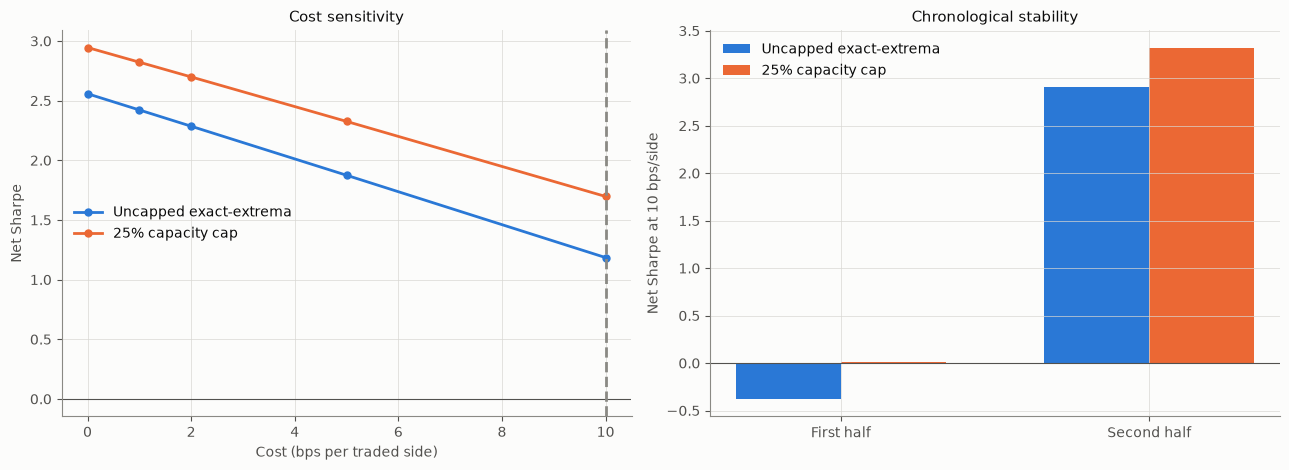

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for arm in ARMS:
    line = cost_curve.loc[cost_curve["arm"].eq(arm)]
    axes[0].plot(
        line["cost_bps_per_side"],
        line["sharpe_net"],
        marker="o",
        color=colours[arm],
        label=labels[arm],
    )
axes[0].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[0].axvline(COST_BPS, color=INK["muted"], linestyle="--")
axes[0].set_xlabel("Cost (bps per traded side)")
axes[0].set_ylabel("Net Sharpe")
axes[0].set_title("Cost sensitivity")
axes[0].legend(loc="best")
half_plot = temporal.pivot(index="period", columns="arm", values="sharpe_net").reindex(
    ["first_half", "second_half"]
)
x = np.arange(len(half_plot))
width = 0.34
for offset, arm in enumerate(ARMS):
    axes[1].bar(
        x + (offset - 0.5) * width,
        half_plot[arm],
        width,
        color=colours[arm],
        label=labels[arm],
    )
axes[1].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].set_xticks(x, ["First half", "Second half"])
axes[1].set_ylabel("Net Sharpe at 10 bps/side")
axes[1].set_title("Chronological stability")
axes[1].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cost_and_temporal_stability.png", dpi=170, bbox_inches="tight")
plt.show()

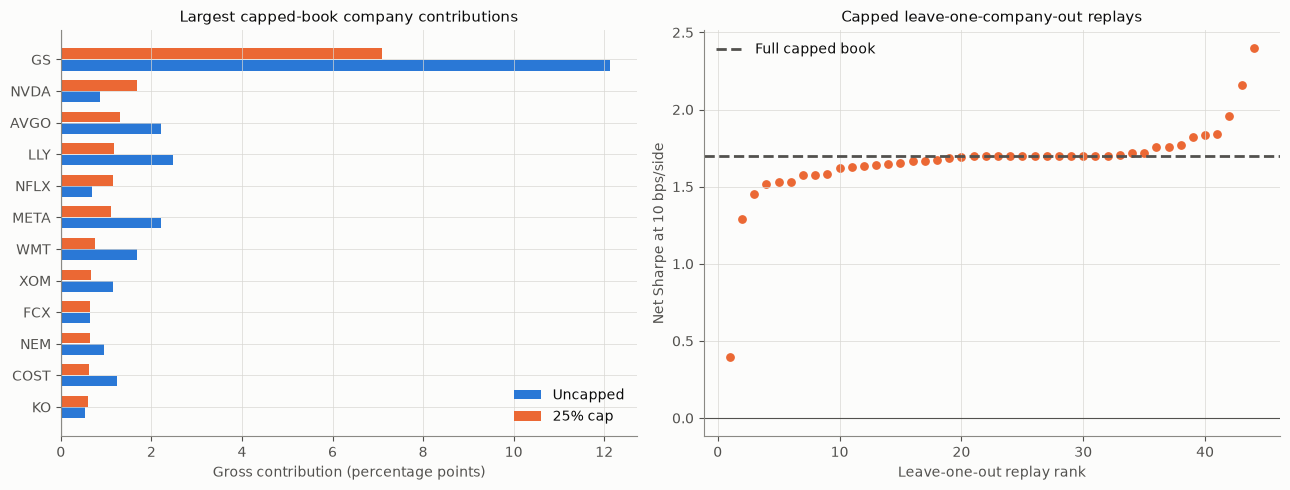

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
top = attribution.head(12).sort_values("capacity_capped_gross_contribution")
y = np.arange(len(top))
axes[0].barh(
    y - 0.18,
    top["uncapped_gross_contribution"] * 100,
    height=0.34,
    color=CATEGORICAL[0],
    label="Uncapped",
)
axes[0].barh(
    y + 0.18,
    top["capacity_capped_gross_contribution"] * 100,
    height=0.34,
    color=CATEGORICAL[1],
    label="25% cap",
)
axes[0].set_yticks(y, top["symbol"])
axes[0].axvline(0.0, color=INK["reference"], linewidth=0.8)
axes[0].set_xlabel("Gross contribution (percentage points)")
axes[0].set_title("Largest capped-book company contributions")
axes[0].legend(loc="lower right")
loo_rank = np.arange(1, len(leave_one_out) + 1)
axes[1].scatter(loo_rank, leave_one_out["sharpe_net"], color=CATEGORICAL[1], s=28)
axes[1].axhline(float(capped["sharpe_net"]), color=INK["reference"], linestyle="--", label="Full capped book")
axes[1].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].set_xlabel("Leave-one-out replay rank")
axes[1].set_ylabel("Net Sharpe at 10 bps/side")
axes[1].set_title("Capped leave-one-company-out replays")
axes[1].legend(loc="upper left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "attribution_and_leave_one_out.png", dpi=170, bbox_inches="tight")
plt.show()

## Persist aggregate outputs and decision

In [13]:
coverage.to_csv(OUTPUT_DIR / "coverage.csv", index=False)
construction_audit.to_csv(OUTPUT_DIR / "construction_audit.csv", index=False)
uncapped_audit.to_csv(OUTPUT_DIR / "uncapped_target_audit.csv", index=False)
capped_audit.to_csv(OUTPUT_DIR / "capped_target_audit.csv", index=False)
reproduction.to_csv(OUTPUT_DIR / "notebook29_reproduction.csv", index=False)
results.to_csv(OUTPUT_DIR / "results.csv", index=False)
paired_inference.to_csv(OUTPUT_DIR / "paired_inference.csv", index=False)
capped_vs_cash.to_csv(OUTPUT_DIR / "capped_vs_cash.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)
temporal.to_csv(OUTPUT_DIR / "temporal_results.csv", index=False)
attribution.to_csv(OUTPUT_DIR / "company_attribution.csv", index=False)
leave_one_out.to_csv(OUTPUT_DIR / "leave_one_out.csv", index=False)
dependence_summary.to_csv(OUTPUT_DIR / "dependence_summary.csv", index=False)
gates.to_csv(OUTPUT_DIR / "gates.csv", index=False)
for arm in ARMS:
    daily_paths[arm].to_parquet(OUTPUT_DIR / f"{arm}_daily.parquet", index=False)
    ledger_paths[arm].to_parquet(OUTPUT_DIR / f"{arm}_ledger.parquet", index=False)

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

manifest = {
    "status": "RETROSPECTIVE_ITERATIVE_NON_POOLED_LSEG_POLICY_AUDIT",
    "notebook": "30_lseg_gemma_capped_extrema_spread.ipynb",
    "git_commit_at_execution": git_commit,
    "seed": SEED,
    "input": {
        "gemma_aggregate_panel": str(GEMMA_PATH.relative_to(REPO_ROOT)),
        "notebook29_manifest": str(NOTEBOOK29_MANIFEST.relative_to(REPO_ROOT)),
        "price_paths": [str(path.relative_to(REPO_ROOT)) for path in PRICE_PATHS],
        "licensed_headline_text_loaded": False,
    },
    "coverage": json.loads(coverage.to_json(orient="records", date_format="iso"))[0],
    "specification": {
        "signal": "unchanged Gemma strongest_event exact +1/-1",
        "single_name_cap": SINGLE_NAME_CAP,
        "leg_budget": "min(0.5, cap*n_positive, cap*n_negative)",
        "same_signs_and_sessions_as_uncapped": True,
        "holding_intervals": 1,
        "cash_on_one_sided_sessions": True,
        "unused_gross_capacity_remains_cash": True,
        "cost_bps_per_traded_side": COST_BPS,
        "drifted_weights_marked_against_after_cost_nav": True,
        "final_liquidation": True,
    },
    "construction_audit": json.loads(construction_audit.to_json(orient="records"))[0],
    "notebook29_reproduction": json.loads(reproduction.to_json(orient="records"))[0],
    "results": json.loads(results.to_json(orient="records")),
    "paired_inference": json.loads(paired_inference.to_json(orient="records")),
    "capped_vs_cash": json.loads(capped_vs_cash.to_json(orient="records"))[0],
    "temporal": json.loads(temporal.to_json(orient="records")),
    "dependence": json.loads(dependence_summary.to_json(orient="records"))[0],
    "gates": json.loads(gates.to_json(orient="records"))[0],
    "limitations": [
        "Notebook 29 results motivated this cap audit on the same opened window",
        "the 25% value was predeclared as Notebook 29's strategy-quality cap, not selected here",
        "eight-month LSEG robustness snapshot is not a pristine confirmatory holdout",
        "capacity scaling reduces gross exposure rather than creating replacement positions",
        "dollar neutrality does not prove beta or sector neutrality",
        "human validation of full-corpus Gemma sentiment remains open",
        "no result is promoted before Gate F1",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))

{
  "status": "RETROSPECTIVE_ITERATIVE_NON_POOLED_LSEG_POLICY_AUDIT",
  "notebook": "30_lseg_gemma_capped_extrema_spread.ipynb",
  "git_commit_at_execution": "8736eebdbb254c8bc6416a09a352f6b5e2f6b1b3",
  "seed": 20260805,
  "input": {
    "gemma_aggregate_panel": "final_experiments/outputs/13_lseg_44_gemma_robustness/gemma4_26b_firm_open_aggregators.parquet",
    "notebook29_manifest": "final_experiments/outputs/29_lseg_gemma_exact_extrema_spread/manifest.json",
    "price_paths": [
      "Data/derived/prices/lseg_us_sector_33_8m.csv",
      "Data/derived/prices/lseg_us_sector_add11_8m.csv"
    ],
    "licensed_headline_text_loaded": false
  },
  "coverage": {
    "firm_open_rows": 7348,
    "sessions": 167,
    "companies": 44,
    "first_entry_session": "2025-10-27T00:00:00.000",
    "last_entry_session": "2026-06-26T00:00:00.000",
    "last_return_end": "2026-06-29T00:00:00.000",
    "max_return_reproduction_error": 0.0
  },
  "specification": {
    "signal": "unchanged Gemma strong

## Decision

The **standalone strategy-quality gate passes**, while the stricter
policy-selection and alpha gates fail. At 10 bps per traded side, the capped
rule raises net Sharpe from **1.185 to 1.697**, cuts maximum drawdown from
**-7.85% to -4.97%**, lowers mean turnover by **40.7%**, and raises estimated
break-even cost from **18.52 to 23.24 bps**. It retains nearly all of the
uncapped net return (**+10.20% versus +10.74%**) despite leaving unused gross
capacity in cash when a leg contains fewer than two firms.

The improvement is a risk-control result, not proof that the cap has a higher
expected return. Capped-minus-uncapped net return averages **-0.514 bps per
session** (95% block-bootstrap CI **[-5.483, +4.291] bps**, p = **0.832**), so
the predeclared policy-selection gate fails. The paired downside-squared loss
does improve, however, and survives the two-test BH family (p = **0.012**).
Against cash, the capped mean is **+5.974 bps per session**, but its 95% CI
still crosses zero (**[-0.973, +13.217] bps**, p = **0.100**), so the alpha
gate also fails.

The stability diagnostics are encouraging but remain exploratory. Capped net
Sharpe is non-negative in both chronological halves (**0.011** and **3.323**),
every one-company-out replay remains positive (minimum Sharpe **0.395**), and
Goldman Sachs' gross-profit share falls from **51.5% to 40.5%**. The exact
25%-cap rule is therefore frozen as the first LSEG/Gemma policy in this chain
to satisfy the predeclared standalone quality gate. It is a credible
risk-controlled strategy candidate for independent time extension, not yet
established alpha or a statistically superior replacement for Notebook 29.